# Multi-Model AutoML LOOCV Pipeline (Baseline 포함)

이 노트북은 **뇌 구조 지표(Morphometric ROI)의 예측 기여도를 검증**하기 위해, 임상 변수만 사용한 Baseline 모델과 뇌 지표를 추가한 5가지 머신러닝 모델의 성능을 비교합니다.

- **Baseline_Clinical_Only**: `vas_t0`, `treatment_group` (2개 변수만 사용)
- **AutoML 모델 5종**: Morphometric ROI(10개, Residualized) + 임상 변수(2개) 사용
- **제거 변수**: age, sex, eTIV
- **타겟 변수**: vas_t1

In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# ==========================================================
# 1. DATA PREPARATION
# ==========================================================
df = pd.read_csv('structural_full_68_68_16_edited.csv', skipinitialspace=True)
df.columns = df.columns.str.strip()

# 10개 ROI 특징
morph_features = [
    'lh_rostralmiddlefrontal_thick', 'rh_rostralmiddlefrontal_thick',
    'lh_Caudate_vol', 'rh_Caudate_vol',
    'lh_Putamen_vol', 'rh_Putamen_vol',
    'lh_Accumbens_vol', 'rh_Accumbens_vol',
    'lh_lateralorbitofrontal_thick', 'lh_rostralanteriorcingulate_thick'
]

nuisance_covariates = ['age', 'sex', 'eTIV']
clinical_predictors = ['vas_t0', 'treatment_group']
target = 'vas_t1'

X_morph = df[morph_features].values
X_nuisance = df[nuisance_covariates].values
X_clinical = df[clinical_predictors].values
y = df[target].values

In [3]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP
# ==========================================================
# Baseline 모델 추가 (임상 변수만 사용)
models = {
    'Baseline_Clinical_Only': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'ElasticNet': {'alpha': [0.01, 0.1, 1.0, 5.0, 10.0], 'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
    'SVR_Linear': {'C': [0.001, 0.01, 0.1, 1.0, 10.0], 'epsilon': [0.01, 0.1, 0.5, 1.0]},
    'SVR_RBF': {'C': [0.001, 0.01, 0.1, 1.0, 10.0], 'gamma': ['scale', 'auto', 0.01, 0.1], 'epsilon': [0.01, 0.1, 0.5, 1.0]},
    'RandomForest': {'n_estimators': [50, 100], 'max_depth': [None, 3, 5], 'min_samples_split': [2, 5]},
    'XGBoost': {'n_estimators': [50, 100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1]}
}

In [4]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
# ==========================================================
loo = LeaveOneOut()
predictions = {name: [] for name in models.keys()}
y_true = []

print(f"Starting LOOCV across {len(models)} models (including Baseline)...\n")

for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X_morph)):
    print(f"Processing fold {fold_idx+1}/{len(y)}...", end='\r')
    
    X_m_train, X_m_test = X_morph[train_idx], X_morph[test_idx]
    X_n_train, X_n_test = X_nuisance[train_idx], X_nuisance[test_idx]
    X_c_train, X_c_test = X_clinical[train_idx], X_clinical[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # --- Nuisance Residualization ---
    nuisance_regressor = LinearRegression()
    nuisance_regressor.fit(X_n_train, X_m_train)
    X_m_train_clean = X_m_train - nuisance_regressor.predict(X_n_train)
    X_m_test_clean = X_m_test - nuisance_regressor.predict(X_n_test)
    
    # --- Features Stack ---
    X_train_full = np.hstack([X_m_train_clean, X_c_train])
    X_test_full = np.hstack([X_m_test_clean, X_c_test])
    
    y_true.append(y_test[0])
    
    for name, model in models.items():
        if name == 'Baseline_Clinical_Only':
            # 임상 변수만 사용하는 모델 (vas_t0, treatment)
            scaler_clin = StandardScaler()
            X_tr_clin = scaler_clin.fit_transform(X_c_train)
            X_te_clin = scaler_clin.transform(X_c_test)
            
            model.fit(X_tr_clin, y_train)
            pred = model.predict(X_te_clin)
            predictions[name].append(pred[0])
            
        else:
            # 뇌 구조 지표가 포함된 모델
            scaler_full = StandardScaler()
            X_tr_full = scaler_full.fit_transform(X_train_full)
            X_te_full = scaler_full.transform(X_test_full)
            
            inner_cv = GridSearchCV(model, param_grids[name], cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
            inner_cv.fit(X_tr_full, y_train)
            pred = inner_cv.best_estimator_.predict(X_te_full)
            predictions[name].append(pred[0])

print("\n\nLOOCV Completed.")

Starting LOOCV across 6 models (including Baseline)...

Processing fold 45/45...

LOOCV Completed.


================ MODEL COMPARISON ================


,Model,MSE,RMSE,R2 Score,Pearson (r),p-value
0,Baseline_Clinical_Only,4.731153,2.175121,0.166181,0.424659,0.003643
3,SVR_RBF,5.267030,2.295001,0.071738,0.302117,0.043692
2,SVR_Linear,5.287007,2.299349,0.068217,0.383158,0.009378
1,ElasticNet,5.403789,2.324605,0.047636,0.289558,0.053692
4,RandomForest,6.065337,2.462790,-0.068956,0.240379,0.111710
5,XGBoost,6.074124,2.464574,-0.070504,0.047509,0.756630


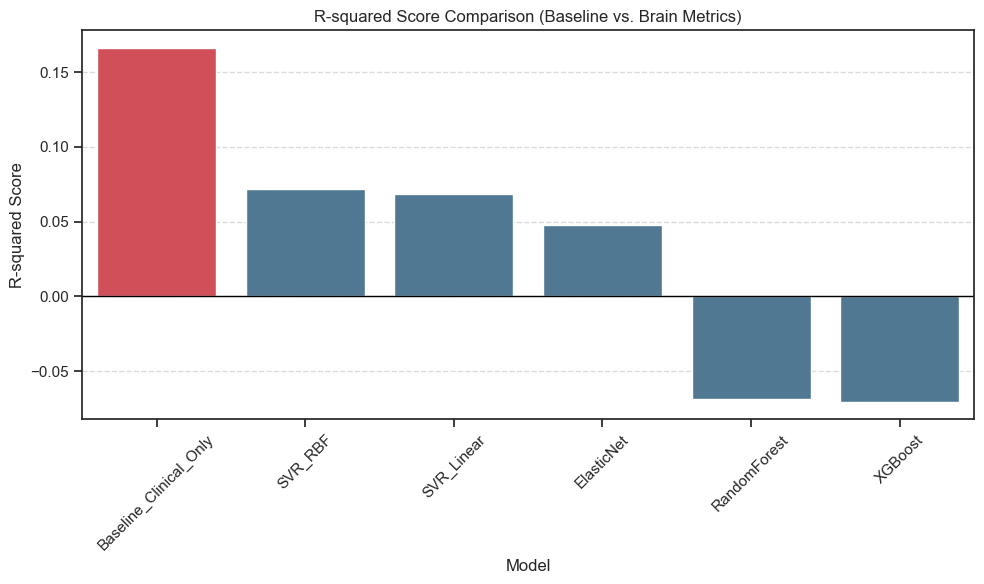

In [5]:
# ==========================================================
# 4. EVALUATION & PERFORMANCE COMPARISON
# ==========================================================
results = []
y_true = np.array(y_true)

for name in models.keys():
    y_pred = np.array(predictions[name])
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    corr, p_val = pearsonr(y_true, y_pred)
    
    results.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2,
        'Pearson (r)': corr,
        'p-value': p_val
    })

results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
print("================ MODEL COMPARISON ================")
display(results_df)

# --- Visualization ---
sns.set_theme(style="ticks")
plt.figure(figsize=(10, 6))

# Baseline은 눈에 띄게 다른 색상으로 표현
colors = ['#E63946' if x == 'Baseline_Clinical_Only' else '#457B9D' for x in results_df['Model']]

ax = sns.barplot(data=results_df, x='Model', y='R2 Score', palette=colors)
plt.title('R-squared Score Comparison (Baseline vs. Brain Metrics)')
plt.ylabel('R-squared Score')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=1) # 0 기준선 추가
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()